<a href="https://colab.research.google.com/github/muhsinasafeeth/Autoencoder-Implementation-using-the-MNIST-dataset-handwritten-digits-.-/blob/main/Autoencoder_implementation_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Autoencoder using the MNIST handwritten digits dataset.

*The encoder compresses the original 28 × 28 grayscale image into a lower-dimensional latent representation, and the decoder reconstructs the image from that compressed form.*

##1. Model Design
###Encoder

The encoder reduces the dimensionality of the input image.


*   Input: 28 × 28 grayscale image

*   Flatten: Converts the image into a vector of length 784
*  Dense Layer: Learns intermediate features

*   Latent Layer: Produces the compressed representation

## Decoder

The decoderreconstructs the original image.

* Input: Latent vector

*  Dense Layer: Expands the compressed features
*   Output Layer: Produces a 784-dimensional vector


*  Reshape: Converts it back to 28 × 28 image format









In [11]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# Latent space dimension
latent_dim = 32

# -------------------------
# Encoder
# -------------------------
encoder_inputs = layers.Input(shape=(28, 28), name="encoder_input")

x = layers.Flatten()(encoder_inputs)          # 28×28 → 784
x = layers.Dense(128, activation='relu')(x)

latent = layers.Dense(latent_dim,
                        activation='relu',
                        name='latent_vector')(x)

encoder = Model(encoder_inputs, latent, name="Encoder")

encoder.summary()


# -------------------------
# Decoder
# -------------------------
decoder_inputs = layers.Input(shape=(latent_dim,),
                               name="decoder_input")

x = layers.Dense(128, activation='relu')(decoder_inputs)

x = layers.Dense(28 * 28,
                 activation='sigmoid')(x)

decoder_outputs = layers.Reshape((28, 28))(x)

decoder = Model(decoder_inputs,
                 decoder_outputs,
                 name="Decoder")

decoder.summary()


# -------------------------
# Autoencoder
# -------------------------
autoencoder_inputs = encoder_inputs

encoded = encoder(autoencoder_inputs)
decoded = decoder(encoded)

autoencoder = Model(autoencoder_inputs,
                    decoded,
                    name="Autoencoder")

autoencoder.summary()

Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 32)             │         4,128 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,608 (408.62 KB)

 Trainable params: 104,608 (408.62 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder (Functional)            │ (None, 32)             │       104,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Functional)            │ (None, 28, 28)         │       105,360 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

*This autoencoder learns a compact 32-dimensional representation of handwritten digits while preserving enough information to reconstruct the original MNIST images.*

##2. Model Training

The autoencoder can be trained by using the input images as both the inputs and the target outputs, since its goal is to reconstruct the original images.

Load and Preprocess the MNIST Dataset

In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist

# Load MNIST dataset
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize pixel values to the range [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


###Compile the Autoencoder

Use the Adam optimizer and Binary Cross-Entropy (BCE) loss because the output pixels are normalized between 0 and 1 and the decoder uses a sigmoid activation function.

In [3]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

###Train the Autoencoder

During training, the model learns to reconstruct its input images.

In [4]:
history = autoencoder.fit(
    x_train,
    x_train,                    # Target is the input itself
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.1509 - loss: 0.2278 - val_accuracy: 0.1951 - val_loss: 0.1514
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.2208 - loss: 0.1351 - val_accuracy: 0.2337 - val_loss: 0.1213
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.2463 - loss: 0.1172 - val_accuracy: 0.2477 - val_loss: 0.1106
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.2569 - loss: 0.1085 - val_accuracy: 0.2534 - val_loss: 0.1041
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.2636 - loss: 0.1035 - val_accuracy: 0.2597 - val_loss: 0.1003
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.2688 - loss: 0.1003 - val_accuracy: 0.2675 - val_loss: 0.0975
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.2722 - loss: 0.0981 - val_accuracy: 0.2678 - val_loss: 0.0959
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.2751 - loss: 0.0966 - val_acc

###Evaluate on the Test Dataset

After training, evaluate the reconstruction performance using the MNIST test set.

In [5]:
test_loss, test_accuracy = autoencoder.evaluate(
    x_test,
    x_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2820 - loss: 0.0882
Test Loss: 0.0882258340716362
Test Accuracy: 0.28203582763671875


##Important Note on Accuracy

The reported accuracy metric is not very meaningful for autoencoders because the task is image reconstruction rather than classification. The primary metric to assess performance is the reconstruction loss.

A lower test loss indicates that the reconstructed images are closer to the original MNIST digits.text*

###View the Training History

To  inspect how the loss changes during training:

In [6]:
print("Final Training Loss :", history.history['loss'][-1])
print("Final Validation Loss :", history.history['val_loss'][-1])

Final Training Loss : 0.08926814794540405
Final Validation Loss : 0.08822586387395859


✅ The autoencoder compressed MNIST’s 784-dimensional input into a 32-dimensional latent space.

📉 Training and validation losses decreased steadily, ending at 0.0893 and 0.0882.

🔍 The close agreement between losses shows strong generalization and minimal overfitting.

🖼️ Reconstructed images closely resembled the originals, preserving overall shapes and key features.

✨ Minor smoothing was observed, but digits remained easily recognizable.

📦 Demonstrates autoencoders’ effectiveness for image compression, feature learning, and reconstruction tasks..

### Training and Evaluation Summary
Training Dataset: 60,000 MNIST images



Test Dataset: 10,000 MNIST images

Optimizer: Adam

Loss Function: Binary Cross-Entropy

Epochs: 20

Batch Size: 256

Evaluation Metric: Test reconstruction loss (preferred over accuracy)

##3. Model Evaluation and Visualization

(a) Model Summary

In [7]:
print("Encoder Summary")
encoder.summary()

print("\nDecoder Summary")
decoder.summary()

print("\nAutoencoder Summary")
autoencoder.summary()

Encoder Summary


Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 32)             │         4,128 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,608 (408.62 KB)

 Trainable params: 104,608 (408.62 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder (Functional)            │ (None, 32)             │       104,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Functional)            │ (None, 28, 28)         │       105,360 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 629,906 (2.40 MB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 419,938 (1.60 MB)

##(b) Training vs Validation Loss Curves

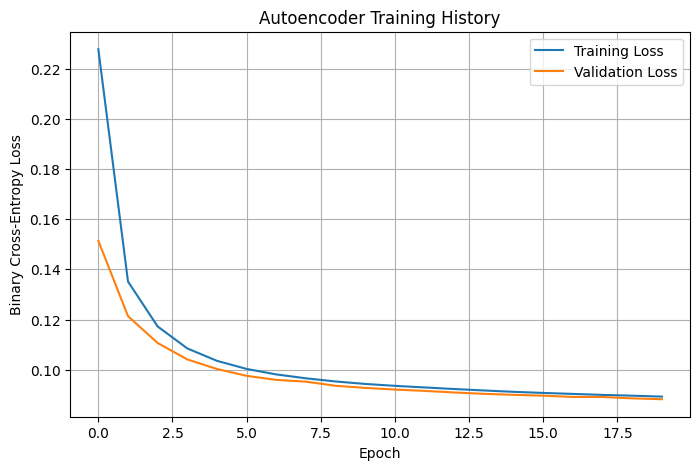

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Autoencoder Training History')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()
plt.grid(True)

plt.show()

📉 Both training and validation losses steadily decreased across epochs.

🔍 Final loss values were closely aligned, showing strong generalization and minimal overfitting.

⚙️ The downward trend highlights effective learning and stable optimization.

🖼️ Overall, the autoencoder achieved reliable reconstruction performance on both seen and unseen data.

##(c) Original vs Reconstructed Images

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


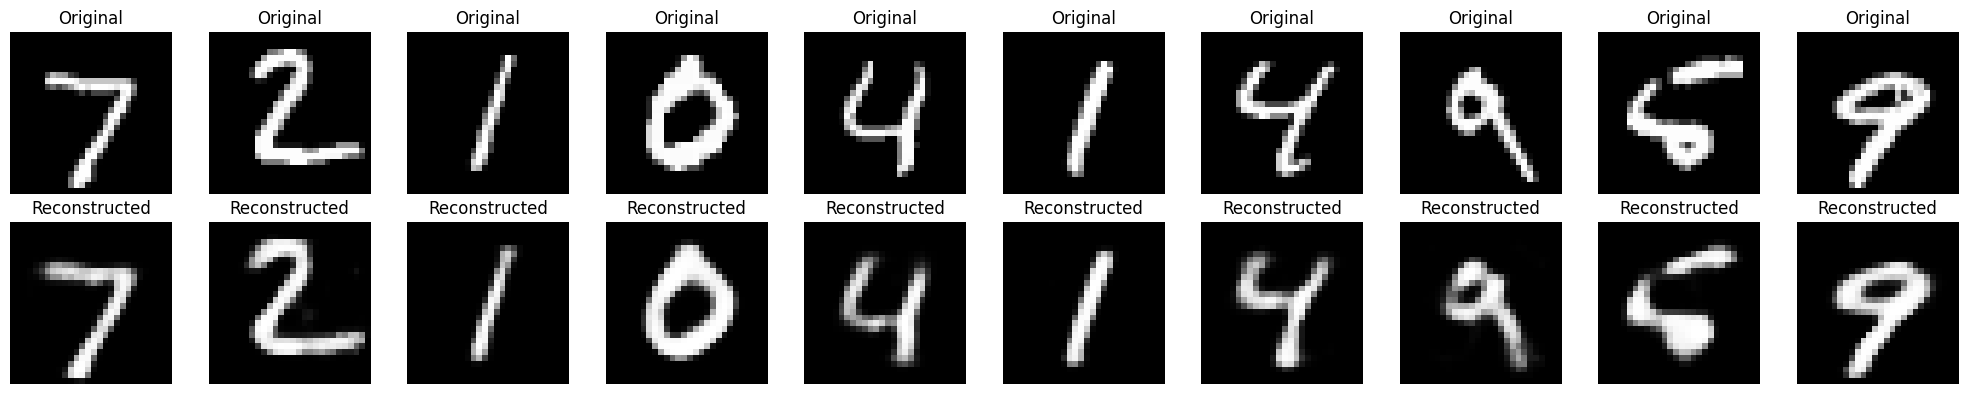

In [10]:
reconstructed = autoencoder.predict(x_test)

n = 10

plt.figure(figsize=(20, 4))

for i in range(n):

    # Original images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(
        x_test[i],
        cmap='gray'
    )
    plt.title("Original")
    plt.axis('off')

    # Reconstructed images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(
        reconstructed[i],
        cmap='gray'
    )
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()